<a href="https://colab.research.google.com/github/7REVOLUTiOn/Computer-Vision-/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%80%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B2%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_Rasterio_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №3. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [ ]:
!pip install rasterio matplotlib
import rasterio
import matplotlib.pyplot as plt
!wget -O dem_90m.tif https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
dem_src = rasterio.open("dem_90m.tif")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 79.6 MB/s eta 0:00:00
--2025-10-28 10:19:44--  https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/772999364/190f4060-f10b-4a8b-8b47-a66fdfd02d19?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-28T11%3A10%3A28Z&rscd=attachment%3B+filename%3Ddem_90m.tif&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-28T10%3A09%3A37Z&ske=2025-10-28T11%3A10%3A28Z&sks=b&skv=2018-11-09&sig=ZwcoqSB6qBYS7f9qflIx1FHqcuvhfdx%2BwtqEjm2U3Ac%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MTY0ODU

2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [ ]:
dem_path = "dem_90m.tif"
with rasterio.open(dem_path) as src:
    crs = src.crs
    resolution = src.res
    bounds = src.bounds
    count = src.count
    dtype = src.dtypes[0]
print("Система координат (CRS):", crs)
print("Разрешение (x, y):", resolution)
print("Границы (left, bottom, right, top):", bounds)
print("Количество каналов:", count)
print("Тип данных пикселей:", dtype)

Система координат (CRS): EPSG:3857
Разрешение (x, y): (90.0, 89.99579177642138)
Границы (left, bottom, right, top): BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Количество каналов: 1
Тип данных пикселей: int16


3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [ ]:
with rasterio.open(dem_path) as src:
    width = src.width
    height = src.height
    pixel_dtype = src.dtypes[0]

print(f"Ширина растра: {width} пикселей")
print(f"Высота растра: {height} пикселей")
print(f"Тип данных пикселей: {pixel_dtype}")

Ширина растра: 4269 пикселей
Высота растра: 3113 пикселей
Тип данных пикселей: int16


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


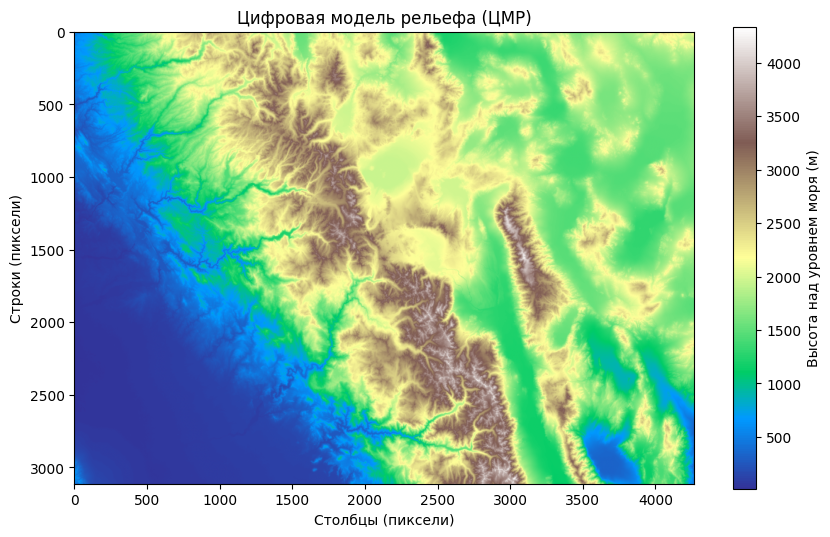

In [ ]:
with rasterio.open(dem_path) as src:
    dem_data = src.read(1)
plt.figure(figsize=(10, 6))
plt.imshow(dem_data, cmap='terrain')
plt.colorbar(label='Высота над уровнем моря (м)')
plt.title('Цифровая модель рельефа (ЦМР)')
plt.xlabel('Столбцы (пиксели)')
plt.ylabel('Строки (пиксели)')
plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


--2025-10-28 10:19:50--  https://github.com/opengeos/datasets/releases/download/raster/cog.tif
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/772999364/8c3a61de-75ab-435b-9c4c-b2d4a289d3ef?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-28T11%3A20%3A25Z&rscd=attachment%3B+filename%3Dcog.tif&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-28T10%3A19%3A29Z&ske=2025-10-28T11%3A20%3A25Z&sks=b&skv=2018-11-09&sig=jJ6ziE4e2SMmyN6ivhnmI1tAx2CiQKWjH4N8lqlVsfI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MTY0NzA5MCwibmJmIjoxNzYxNjQ2NzkwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2luZG93

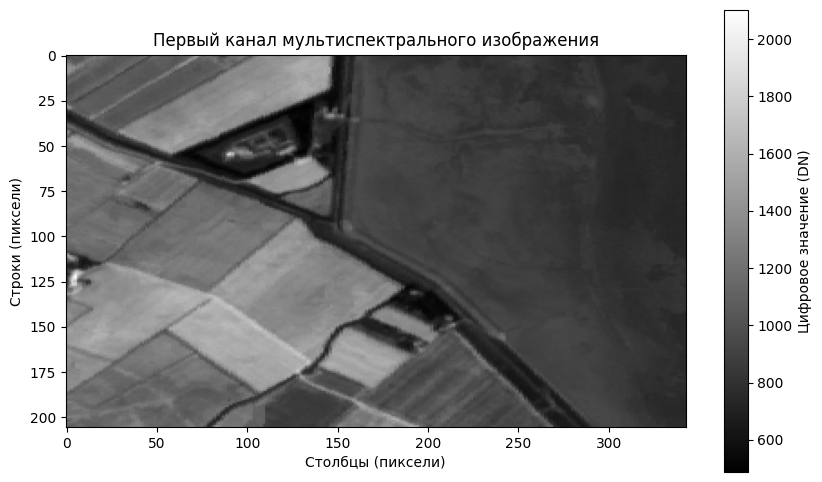

In [ ]:
landsat_path = "cog.tif"
import os
if not os.path.exists(landsat_path):
    !wget -O {landsat_path} https://github.com/opengeos/datasets/releases/download/raster/cog.tif
with rasterio.open(landsat_path) as src:
    first_band = src.read(1)

plt.figure(figsize=(10, 6))
plt.imshow(first_band, cmap='gray')
plt.colorbar(label='Цифровое значение (DN)')
plt.title('Первый канал мультиспектрального изображения')
plt.xlabel('Столбцы (пиксели)')
plt.ylabel('Строки (пиксели)')
plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

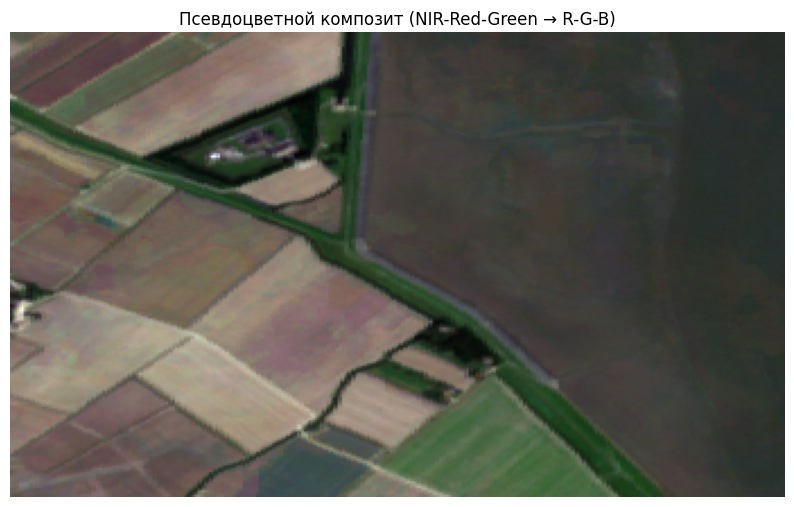

In [ ]:
import numpy as np
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    return (band - band_min) / (band_max - band_min + 1e-8)

with rasterio.open(landsat_path) as src:
    nir = src.read(1).astype('float32')
    red = src.read(2).astype('float32')
    green = src.read(3).astype('float32')

nir_norm = normalize(nir)
red_norm = normalize(red)
green_norm = normalize(green)

rgb_false = np.stack([nir_norm, red_norm, green_norm], axis=2)

plt.figure(figsize=(10, 8))
plt.imshow(rgb_false)
plt.title('Псевдоцветной композит (NIR-Red-Green → R-G-B)')
plt.axis('off')
plt.show()

---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [ ]:
row_start, row_end = 200, 600
col_start, col_end = 300, 800
with rasterio.open(landsat_path) as src:
    full_data = src.read()
    clipped_data = full_data[:, row_start:row_end, col_start:col_end]
print("Форма исходного изображения:", full_data.shape)
print("Форма обрезанного изображения:", clipped_data.shape)

Форма исходного изображения: (4, 206, 343)
Форма обрезанного изображения: (4, 6, 43)


2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

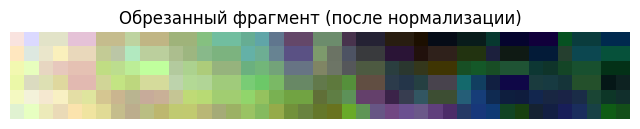

In [ ]:
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
r_norm = normalize(clipped_data[0])
g_norm = normalize(clipped_data[1])
b_norm = normalize(clipped_data[2])
rgb_clipped = np.stack([r_norm, g_norm, b_norm], axis=2)
plt.figure(figsize=(8, 6))
plt.imshow(rgb_clipped)
plt.title('Обрезанный фрагмент (после нормализации)')
plt.axis('off')
plt.show()


3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [ ]:
with rasterio.open("cog.tif") as src:
    meta = src.meta.copy()
meta.update({
    'height': clipped_data.shape[1],
    'width': clipped_data.shape[2]
})
with rasterio.open("clipped_multispectral.tif", 'w', **meta) as dst:
    dst.write(clipped_data)

---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [ ]:
with rasterio.open("cog.tif") as src:

    nir = src.read(1).astype('float32')
    green = src.read(3).astype('float32')

2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [ ]:
ndwi = (green - nir) / (green + nir + 1e-8)

3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


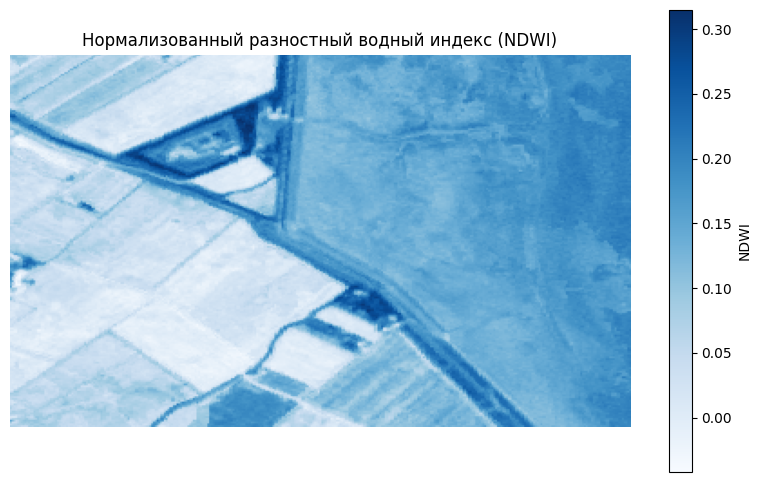

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(ndwi, cmap='Blues')
plt.colorbar(label='NDWI')
plt.title('Нормализованный разностный водный индекс (NDWI)')
plt.axis('off')
plt.show()



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [ ]:
with rasterio.open("cog.tif") as src:
    meta = src.meta.copy()
meta.update(count=1, dtype='float32')
with rasterio.open("ndwi.tif", 'w', **meta) as dst:
    dst.write(ndwi.astype('float32'), 1)

---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [ ]:
from rasterio.warp import reproject, Resampling, calculate_default_transform
with rasterio.open("dem_90m.tif") as src:
    src_data = src.read(1)
    src_crs = src.crs
    src_transform = src.transform
    src_meta = src.meta
dst_crs = "EPSG:4326"
transform, width, height = calculate_default_transform(
    src_crs, dst_crs, src.width, src.height, *src.bounds
)
reprojected_data = np.empty((height, width), dtype=src_data.dtype)
reproject(
    source=src_data,
    destination=reprojected_data,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=transform,
    dst_crs=dst_crs,
    resampling=Resampling.bilinear
)

(array([[ 582,  586,  594, ..., 1995, 2017, 2029],
        [ 600,  609,  617, ..., 1969, 1987, 2003],
        [ 612,  621,  627, ..., 1948, 1970, 1995],
        ...,
        [ 550,  543,  567, ...,  452,  448,  443],
        [ 534,  535,  561, ...,  455,  449,  441],
        [ 522,  521,  543, ...,  447,  449,  447]], dtype=int16),
 Affine(0.0007543273324700005, 0.0, -120.75592734935736,
        0.0, -0.0007543273324700005, 38.62692343418839))

2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [ ]:
reprojected_meta = src_meta.copy()
reprojected_meta.update({
    'crs': 'EPSG:4326',
    'transform': transform,
    'width': width,
    'height': height
})
with rasterio.open("reprojected_dem.tif", 'w', **reprojected_meta) as dst:
    dst.write(reprojected_data, 1)

3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

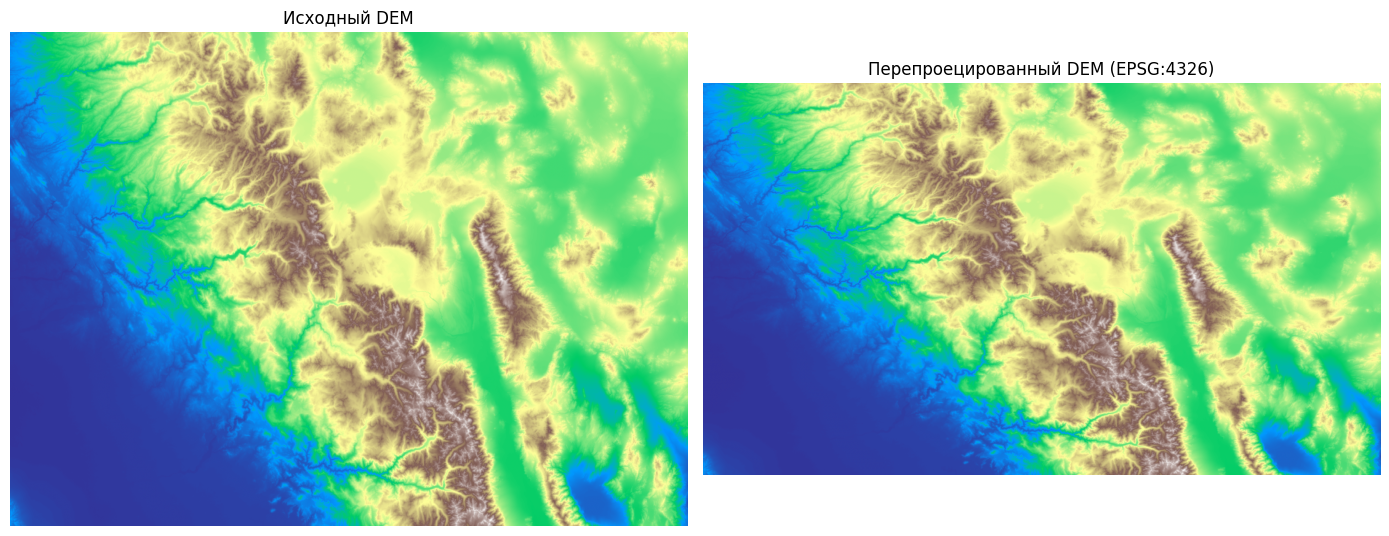

In [ ]:
with rasterio.open("dem_90m.tif") as src:
    dem_original = src.read(1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(dem_original, cmap='terrain')
axes[0].set_title('Исходный DEM')
axes[0].axis('off')
axes[1].imshow(reprojected_data, cmap='terrain')
axes[1].set_title('Перепроецированный DEM (EPSG:4326)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---